<div style="background-color:#F3F2EE">
    <br /><br />
        <p style="text-align: center;">
            <font size="6" color='#0A1781'>
                <strong>
                    NLP Triagem Inteligente Financeira - Data Science Project
                </strong>
              </font>
        </p>
        <p style="text-align: center;">
            <font size="6" color='#C58A1E'>
                <strong>
                    Modeling Advanced | Transformer Text Classifier
                </strong>
            </font>
        </p>
        <p style="text-align: center;">
            <font size="5" color='#C58A1E'>
                <strong>
                    Treinar e avaliar um classificador textual baseado em transformer<br />para comparar seu desempenho com o baseline clássico construído.
                </strong>
            </font>
        </p>
    <br />
</div>

<div style="background-color:#F3F2EE">
    <p style="text-align: right;">
      <font size="4" color='#444444'>
            Roberto SSoares - LfLngLrnng
      </font>
    </p>
    <p style="text-align: right;"><font size="2" color='#444444'>
        <a href="https://www.linkedin.com/in/roberto-dos-santos-soares/">in/roberto-dos-santos-soares</a><br /><a href="https://roberto-ssoares.github.io/meu-portfolio/">Portifólio: roberto-ssoares</a>
    </p>
    <p style="text-align: right;">
        <font size="4" color='#444444'>
            " [+] Faturamento [-] Custo [+] Qualidade de vida "
        </font>
        <br />
        <font size="2" color='#918e8e'>"Mestre Bruno Jardim"
        </font>
    </p>        
    <p style="text-align: right;">        
        <font size="2" color='#918e8e'>           
        </font>
    </p>
</div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 Objetivo:</strong></font>

<font size="2" color='#66666'>

>- **Ações realizadas neste notebook**
    - ***Leitura das bases gold de treino, validação e teste***
    - ***Definição do modelo transformer e do tokenizer***
    - ***Preparação dos dados para fine-tuning***
    - ***Treino supervisionado com validação***
    - ***Avaliação no conjunto de teste***
    - ***Comparação com o baseline***
    - ***Persistência dos artefatos do modelo avançado***

>- **Justificativa técnica**
    - Transformers são especialmente úteis em tarefas de NLP onde a **semântica contextual** importa mais do que simples frequência de termos.
    - Neste projeto, o objetivo é medir o ganho real do modelo avançado sobre o baseline TF-IDF + Regressão Logística.

>- **Resultados esperados**
    - Modelo transformer treinado
    - Métricas registradas em validação e teste
    - Comparação objetiva com o baseline
    - Artefatos persistidos para reuso

---

</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 Leitura executiva da etapa</strong></font>

<font size="2" color='#66666'>

>- Este notebook representa a camada de **NLP avançado** do projeto.

>- A proposta aqui é avaliar se um modelo transformer consegue superar o baseline clássico, especialmente em cenários como:
    - **classes semanticamente próximas**
    - **perguntas curtas e ambíguas**
    - **taxonomia multiclasses mais complexa**

>- **Nota metodológica**
    - O processo seguirá a mesma disciplina do baseline:
        - treino em `train`
        - seleção em `valid`
        - avaliação final em `test`

---

</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 1 — Setup do ambiente e leitura das bases</strong></font>

<font size="2" color='#66666'>
    
>- **Objetivo da seção**
    - Preparar o ambiente de treino com transformers e carregar os dados necessários para o fine-tuning supervisionado.

>- **Ações realizadas**
    - ***Importação das bibliotecas***
    - ***Definição dos paths do projeto***
    - ***Leitura das bases gold***
    - ***Leitura do mapping de labels***
    - ***Leitura das métricas do baseline para comparação posterior***

>- **Justificativa técnica**
    - O setup explícito garante reprodutibilidade, organização e integração futura com o restante do pipeline.

>- **Resultados esperados**
    - Ambiente pronto para fine-tuning
    - Bases carregadas corretamente
    - Baseline disponível para comparação

---
</font></div>

In [28]:
import warnings
from pathlib import Path
import json
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [4]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 200)

In [5]:
PROJECT_ROOT = Path.cwd().resolve().parents[0]
DATA_DIR = PROJECT_ROOT / "data"

GOLD_DIR = DATA_DIR / "03-gold"
TRANSFORMER_MODELS_DIR = PROJECT_ROOT / "models" / "transformer"
REPORTS_DIR = PROJECT_ROOT / "artifacts" / "reports"
FIGURES_DIR = PROJECT_ROOT / "artifacts" / "figures"

TRANSFORMER_MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT         :", PROJECT_ROOT)
print("GOLD_DIR             :", GOLD_DIR)
print("TRANSFORMER_MODELS_DIR:", TRANSFORMER_MODELS_DIR)
print("REPORTS_DIR          :", REPORTS_DIR)
print("FIGURES_DIR          :", FIGURES_DIR)
print("CUDA disponível?     :", torch.cuda.is_available())

PROJECT_ROOT         : D:\_DS-Projects\nlp-triagem-inteligente-financeira
GOLD_DIR             : D:\_DS-Projects\nlp-triagem-inteligente-financeira\data\03-gold
TRANSFORMER_MODELS_DIR: D:\_DS-Projects\nlp-triagem-inteligente-financeira\models\transformer
REPORTS_DIR          : D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\reports
FIGURES_DIR          : D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\figures
CUDA disponível?     : False


<div style="background-color:#f3f2ee">
    
<font size="3" color='#CC403E'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

>- Este notebook reutiliza os dados preparados no Notebook 03 e compara seu desempenho com o baseline salvo no Notebook 04.

---
</font></div>

In [6]:
train_path = GOLD_DIR / "faq_bacen_gold_train.csv"
valid_path = GOLD_DIR / "faq_bacen_gold_valid.csv"
test_path = GOLD_DIR / "faq_bacen_gold_test.csv"
label_mapping_path = GOLD_DIR / "label_mapping.csv"

baseline_metrics_path = REPORTS_DIR / "baseline_test_metrics.csv"

train_gold = pd.read_csv(train_path)
valid_gold = pd.read_csv(valid_path)
test_gold = pd.read_csv(test_path)
label_mapping_df = pd.read_csv(label_mapping_path).sort_values("label_id")

baseline_test_metrics_df = pd.read_csv(baseline_metrics_path)

print("train_gold:", train_gold.shape)
print("valid_gold:", valid_gold.shape)
print("test_gold :", test_gold.shape)
print("label_mapping_df:", label_mapping_df.shape)
print("baseline_test_metrics_df:", baseline_test_metrics_df.shape)

train_gold: (1044, 8)
valid_gold: (261, 8)
test_gold : (373, 8)
label_mapping_df: (242, 2)
baseline_test_metrics_df: (1, 5)


In [7]:
label_ids = label_mapping_df["label_id"].tolist()
label_names = label_mapping_df["category_final"].tolist()

id_to_label = dict(zip(label_mapping_df["label_id"], label_mapping_df["category_final"]))
label_to_id = dict(zip(label_mapping_df["category_final"], label_mapping_df["label_id"]))

N_LABELS = len(label_ids)

print("Número de labels:", N_LABELS)
print("Primeiras labels:", label_names[:10])

Número de labels: 242
Primeiras labels: ['Acordo Administrativo em Processo de Supervisão (APS)', 'Alerta contra golpes envolvendo o nome do Banco Central e de instituições financeiras', 'Aplicações financeiras', 'Arranjos de Pagamentos Compras e relações de consumo', 'Arranjos de Pagamentos Conceitos importantes', 'Arranjos de Pagamentos Informações Gerais', 'Arranjos de Pagamentos Interoperabilidade, liquidação centralizada e compulsório', 'Arranjos de Pagamentos Supervisão dos arranjos pelo BC', 'Atendimento bancário (fila, feriados e outros)', 'Bacen Jud e SISBAJUD Informações gerais']


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 2 — Definição do texto de entrada e escolha do modelo</strong></font>

<font size="2" color='#66666'>
    
>- **Objetivo da seção**
    - Definir a coluna textual que será utilizada no transformer e selecionar o checkpoint inicial do modelo.

>- **Ações realizadas**
    - ***Escolha da coluna textual***
    - ***Escolha do checkpoint pré-treinado***
    - ***Registro da estratégia inicial do experimento***

>- **Justificativa técnica**
    - Diferentemente do baseline, **transformers costumam se beneficiar de um texto menos agressivamente limpo, preservando melhor sinal contextual**.

>- **Resultados esperados**
    - Texto de entrada definido
    - Modelo base escolhido
    - Experimento pronto para tokenização

---
</font></div>

In [8]:
TEXT_COL = "question_clean_light"
TARGET_COL = "label_id"

MODEL_CHECKPOINT = "neuralmind/bert-base-portuguese-cased"
MAX_LENGTH = 128

print("TEXT_COL         :", TEXT_COL)
print("TARGET_COL       :", TARGET_COL)
print("MODEL_CHECKPOINT :", MODEL_CHECKPOINT)
print("MAX_LENGTH       :", MAX_LENGTH)

TEXT_COL         : question_clean_light
TARGET_COL       : label_id
MODEL_CHECKPOINT : neuralmind/bert-base-portuguese-cased
MAX_LENGTH       : 128


In [9]:
train_gold[[TEXT_COL, "category_final", TARGET_COL]].sample(5, random_state=42)

,question_clean_light,category_final,label_id
971,é necessário emitir boleto de pagamento para realização da portabilidade?,Portabilidade de Crédito Procedimentos,176
280,onde posso consultar os escritórios de representação de instituições financeiras estrangeiras?,Processos de Autorização do Banco Central Informações Gerais,189
536,posso obter um empréstimo em uma cooperativa de crédito?,SEM-CATEGORIA,217
824,com que frequência as instituições deverão enviar as informações de valores a receber?,Valores a Receber,241
644,quero abrir uma conta no exterior. como faço?,Contas de brasileiros no exterior e de estrangeiros no Brasil Contas de brasileiros no exterior,71


<div style="background-color:#f3f2ee">
    
<font size="3" color='#CC403E'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

>- A coluna escolhida para o transformer é `question_clean_light`, pois ela preserva melhor a estrutura textual em comparação com a limpeza mais agressiva usada no baseline clássico.

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 3 — Preparação dos datasets para fine-tuning</strong></font>

<font size="2" color='#66666'>
    
>- **Objetivo da seção**
    - Converter os dados tabulares em datasets compatíveis com o ecossistema Hugging Face e aplicar tokenização.

>- **Ações realizadas**
    - ***Seleção das colunas de entrada***
    - ***Conversão para `Dataset`***
    - ***Tokenização com truncamento***
    - ***Criação do data collator***

>- **Justificativa técnica**
    - O fine-tuning com transformers requer dados estruturados em formato adequado para batching, padding dinâmico e treino supervisionado.

>- **Resultados esperados**
    - Datasets tokenizados para treino, validação e teste
    - Pipeline de entrada pronto para o trainer

---
</font></div>

In [10]:
train_df = train_gold[[TEXT_COL, TARGET_COL, "category_final"]].copy()
valid_df = valid_gold[[TEXT_COL, TARGET_COL, "category_final"]].copy()
test_df = test_gold[[TEXT_COL, TARGET_COL, "category_final"]].copy()

train_df = train_df.rename(columns={TEXT_COL: "text", TARGET_COL: "label"})
valid_df = valid_df.rename(columns={TEXT_COL: "text", TARGET_COL: "label"})
test_df = test_df.rename(columns={TEXT_COL: "text", TARGET_COL: "label"})

train_hf = Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False)
valid_hf = Dataset.from_pandas(valid_df[["text", "label"]], preserve_index=False)
test_hf = Dataset.from_pandas(test_df[["text", "label"]], preserve_index=False)

train_hf, valid_hf, test_hf

(Dataset({
     features: ['text', 'label'],
     num_rows: 1044
 }),
 Dataset({
     features: ['text', 'label'],
     num_rows: 261
 }),
 Dataset({
     features: ['text', 'label'],
     num_rows: 373
 }))

In [11]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
tokenizer

BertTokenizer(name_or_path='neuralmind/bert-base-portuguese-cased', vocab_size=29794, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [12]:
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

train_tokenized = train_hf.map(tokenize_batch, batched=True)
valid_tokenized = valid_hf.map(tokenize_batch, batched=True)
test_tokenized = test_hf.map(tokenize_batch, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/1044 [00:00<?, ? examples/s]

Map:   0%|          | 0/261 [00:00<?, ? examples/s]

Map:   0%|          | 0/373 [00:00<?, ? examples/s]

In [13]:
train_tokenized[0]

{'text': 'o que é unidade de recebíveis?',
 'label': 154,
 'input_ids': [101, 146, 179, 253, 3812, 125, 2663, 1686, 136, 102],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 4 — Construção do modelo e definição das métricas</strong></font>

<font size="2" color='#66666'>

>- **Objetivo da seção**
    - Instanciar o modelo transformer para classificação multiclasses e definir a função de métricas usada pelo trainer.

>- **Ações realizadas**
    - ***Carregamento do modelo pré-treinado***
    - ***Definição do número de labels***
    - ***Definição da função de métricas***

>- **Justificativa técnica**
    - A comparação com o baseline exige métricas equivalentes, especialmente Macro F1, Weighted F1 e Accuracy.

>- **Resultados esperados**
    - Modelo pronto para fine-tuning
    - Função de avaliação pronta para treino e validação

---
</font></div>

In [14]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=N_LABELS,
    id2label=id_to_label,
    label2id=label_to_id,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. C

In [15]:
def compute_transformer_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "weighted_f1": f1_score(labels, preds, average="weighted", zero_division=0),
        "macro_precision": precision_score(labels, preds, average="macro", zero_division=0),
        "macro_recall": recall_score(labels, preds, average="macro", zero_division=0),
    }

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 5 — Treino supervisionado com validação</strong></font>

<font size="2" color='#66666'>

>- **Objetivo da seção**
    - Executar o fine-tuning supervisionado do transformer utilizando treino e validação.

>- **Ações realizadas**
    - ***Definição dos argumentos de treino***
    - ***Instanciação do Trainer***
    - ***Treino do modelo***
    - ***Avaliação na validação***

>- **Justificativa técnica**
    - Nesta etapa buscamos medir o ganho do modelo contextual em relação ao baseline, preservando a disciplina metodológica do holdout.

>- **Resultados esperados**
    - Modelo treinado
    - Métricas de validação registradas
    - Melhor checkpoint salvo

---
</font></div>

In [16]:
OUTPUT_DIR = TRANSFORMER_MODELS_DIR / "bertimbau_faq_bacen"

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
)

In [22]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=valid_tokenized,
    processing_class=tokenizer,
    #tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_transformer_metrics,
)


In [23]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,5.135564,5.073109,0.130268,0.001695,0.030028,0.000958,0.007353
2,4.828647,4.964398,0.130268,0.001695,0.030028,0.000958,0.007353
3,4.672442,4.911575,0.130268,0.001695,0.030028,0.000958,0.007353


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

In [25]:
valid_metrics = trainer.evaluate(valid_tokenized)
valid_metrics

{'eval_loss': 5.0641913414001465,
 'eval_accuracy': 0.13026819923371646,
 'eval_macro_f1': 0.001694915254237288,
 'eval_weighted_f1': 0.030027923891161764,
 'eval_macro_precision': 0.0009578544061302681,
 'eval_macro_recall': 0.007352941176470588}

<div style="background-color:#f3f2ee">
    
<font size="3" color='#CC403E'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

>- As métricas de validação aqui terão papel equivalente ao do Notebook 04: elas servem para validar a consistência do modelo antes da leitura final em teste.

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 6 — Avaliação final no conjunto de teste</strong></font>

<font size="2" color='#66666'>
    
>- **Objetivo da seção**
    - Medir a generalização do transformer em dados não utilizados no treino nem na seleção do melhor checkpoint.

>- **Ações realizadas**
    - ***Predição no conjunto de teste***
    - ***Cálculo das métricas globais***
    - ***Construção do relatório por classe***
    - ***Criação da base de previsões do teste***

>- **Justificativa técnica**
    - O conjunto de teste fornece a leitura mais honesta do ganho real do transformer sobre o baseline.

>- **Resultados esperados**
    - Métricas finais do transformer
    - Relatório por classe
    - Base pronta para análise qualitativa

---
</font></div>

In [26]:
test_output = trainer.predict(test_tokenized)

test_logits = test_output.predictions
test_pred = np.argmax(test_logits, axis=-1)
y_test = test_df["label"].values

transformer_test_metrics = {
    "accuracy": accuracy_score(y_test, test_pred),
    "macro_f1": f1_score(y_test, test_pred, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_test, test_pred, average="weighted", zero_division=0),
    "macro_precision": precision_score(y_test, test_pred, average="macro", zero_division=0),
    "macro_recall": recall_score(y_test, test_pred, average="macro", zero_division=0),
}

transformer_test_metrics

{'accuracy': 0.1769436997319035,
 'macro_f1': 0.0020594751458794893,
 'weighted_f1': 0.0532040281654015,
 'macro_precision': 0.0012119431488486542,
 'macro_recall': 0.00684931506849315}

In [27]:
transformer_test_metrics_df = pd.DataFrame([transformer_test_metrics])
transformer_test_metrics_df.style.format(
    {
        "accuracy": "{:.4f}",
        "macro_f1": "{:.4f}",
        "weighted_f1": "{:.4f}",
        "macro_precision": "{:.4f}",
        "macro_recall": "{:.4f}",
    }
)

,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,0.1769,0.0021,0.0532,0.0012,0.0068


In [29]:
test_report_dict = classification_report(
    y_test,
    test_pred,
    labels=label_ids,
    target_names=label_names,
    output_dict=True,
    zero_division=0,
)

transformer_test_report_df = pd.DataFrame(test_report_dict).T
transformer_test_class_report = transformer_test_report_df.loc[label_names].copy()
transformer_test_class_report = transformer_test_class_report.sort_values(
    by="f1-score",
    ascending=False
)

transformer_test_class_report.head(20)

,precision,recall,f1-score,support
SEM-CATEGORIA,0.176944,1.0,0.300683,66.0
Acordo Administrativo em Processo de Supervisão (APS),0.000000,0.0,0.000000,0.0
Aplicações financeiras,0.000000,0.0,0.000000,3.0
Arranjos de Pagamentos Compras e relações de consumo,0.000000,0.0,0.000000,1.0
Arranjos de Pagamentos Conceitos importantes,0.000000,0.0,0.000000,2.0
Arranjos de Pagamentos Informações Gerais,0.000000,0.0,0.000000,0.0
"Arranjos de Pagamentos Interoperabilidade, liquidação centralizada e compulsório",0.000000,0.0,0.000000,2.0
Arranjos de Pagamentos Supervisão dos arranjos pelo BC,0.000000,0.0,0.000000,0.0
"Atendimento bancário (fila, feriados e outros)",0.000000,0.0,0.000000,4.0
Bacen Jud e SISBAJUD Informações gerais,0.000000,0.0,0.000000,0.0


In [30]:
transformer_test_predictions_df = test_gold.copy()
transformer_test_predictions_df["y_true"] = y_test
transformer_test_predictions_df["y_pred"] = test_pred
transformer_test_predictions_df["true_label"] = transformer_test_predictions_df["y_true"].map(id_to_label)
transformer_test_predictions_df["pred_label"] = transformer_test_predictions_df["y_pred"].map(id_to_label)
transformer_test_predictions_df["is_error"] = (
    transformer_test_predictions_df["y_true"] != transformer_test_predictions_df["y_pred"]
)

transformer_test_predictions_df[[
    "question_raw",
    "true_label",
    "pred_label",
    "is_error"
]].head(15)

,question_raw,true_label,pred_label,is_error
0,Qual a diferença entre credenciadores e subcredenciadores?,Instituições de Pagamento,SEM-CATEGORIA,True
1,O cliente pode revogar o consentimento anterior?,Open Banking Autorização do cliente para compartilhamento de seus dados,SEM-CATEGORIA,True
2,O que devo fazer se suspeitar que uma cédula pode ser falsa?,"Cédula de R$200,00 Itens de segurança e falsificações",SEM-CATEGORIA,True
3,"Com o Pix, a TED e o DOC vão acabar?","Pagamento Instantâneo (Pix) Entendendo a diferença entre o Pix e os outros meios de pagamento (TED, DOC, boleto bancário e cartões)",SEM-CATEGORIA,True
4,Todas as operações de câmbio de uma instituição compõem a média calculada para classificação?,SEM-CATEGORIA,SEM-CATEGORIA,False
5,Como se classificam os recursos do crédito rural?,SEM-CATEGORIA,SEM-CATEGORIA,False
6,Quando os recursos livres de clientes em posse da corretora serão liberados?,Liquidação Extrajudicial - Corretoras de Títulos e Valores Mobiliários,SEM-CATEGORIA,True
7,"Quero efetuar o pagamento de uma conta com um cheque, mas o banco se recusa a receber. O procedimento do banco está correto?",Cheques Talão de cheque,SEM-CATEGORIA,True
8,Quais dados estão contidos no CCS?,Cadastro de Clientes do Sistema Financeiro Nacional (CCS) Dados do CCS,SEM-CATEGORIA,True
9,Quais são as condições básicas dos créditos de investimento do Pronaf - Floresta?,Programa Nacional de Fortalecimento da Agricultura Familiar - Pronaf,SEM-CATEGORIA,True


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 7 — Comparação com o baseline</strong></font>

<font size="2" color='#66666'>
    
>- **Objetivo da seção**
    - Comparar o desempenho do transformer com o baseline clássico do Notebook 04.

>- **Ações realizadas**
    - ***Leitura das métricas do baseline***
    - ***Consolidação das métricas do transformer***
    - ***Montagem de tabela comparativa***

>- **Justificativa técnica**
    - O objetivo desta etapa não é apenas medir o transformer isoladamente, mas verificar se ele entrega ganho prático e justificável sobre a linha de base.

>- **Resultados esperados**
    - Comparação objetiva entre baseline e transformer
    - Evidência do valor incremental do modelo avançado


</font></div>

In [31]:
baseline_metrics = baseline_test_metrics_df.iloc[0].to_dict()

comparison_df = pd.DataFrame(
    [
        {"model": "baseline_tfidf_logreg", **baseline_metrics},
        {"model": "transformer_bertimbau", **transformer_test_metrics},
    ]
)

comparison_df

,model,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,baseline_tfidf_logreg,0.302949,0.236813,0.302842,0.255719,0.263999
1,transformer_bertimbau,0.176944,0.002059,0.053204,0.001212,0.006849


In [32]:
comparison_df.style.format(
    {
        "accuracy": "{:.4f}",
        "macro_f1": "{:.4f}",
        "weighted_f1": "{:.4f}",
        "macro_precision": "{:.4f}",
        "macro_recall": "{:.4f}",
    }
)

,model,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,baseline_tfidf_logreg,0.3029,0.2368,0.3028,0.2557,0.2640
1,transformer_bertimbau,0.1769,0.0021,0.0532,0.0012,0.0068


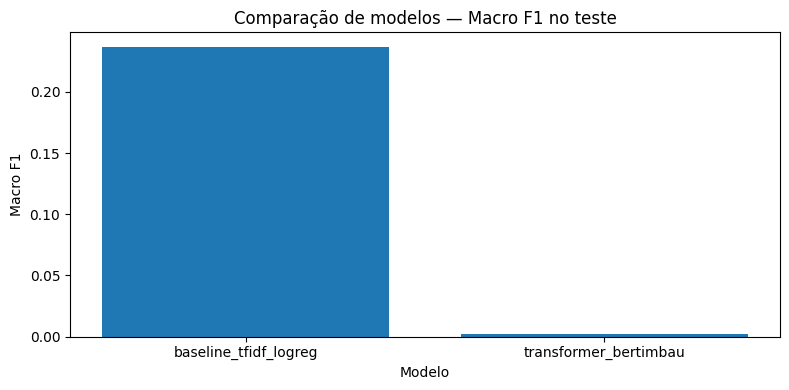

In [33]:
plt.figure(figsize=(8, 4))
plt.bar(comparison_df["model"], comparison_df["macro_f1"])
plt.title("Comparação de modelos — Macro F1 no teste")
plt.ylabel("Macro F1")
plt.xlabel("Modelo")
plt.tight_layout()
plt.show()

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 8 — Persistência dos artefatos do modelo avançado</strong></font>

<font size="2" color='#66666'>

>- **Objetivo da seção**
    - Salvar os principais artefatos produzidos no experimento transformer.

>- **Ações realizadas**
    - ***Salvamento do tokenizer***
    - ***Salvamento do modelo***
    - ***Persistência das métricas***
    - ***Persistência da comparação com baseline***
    - ***Persistência das previsões do teste***

>- **Justificativa técnica**
    - Persistir os artefatos garante reprodutibilidade, rastreabilidade e integração futura com API e monitoramento.

>- **Resultados esperados**
    - Modelo e tokenizer salvos
    - Resultados do experimento persistidos

</font></div>

In [34]:
trainer.save_model(str(OUTPUT_DIR))
tokenizer.save_pretrained(str(OUTPUT_DIR))

transformer_metrics_path = REPORTS_DIR / "transformer_test_metrics.csv"
transformer_report_path = REPORTS_DIR / "transformer_test_classification_report.csv"
transformer_predictions_path = REPORTS_DIR / "transformer_test_predictions.csv"
comparison_path = REPORTS_DIR / "baseline_vs_transformer_comparison.csv"
transformer_metadata_path = TRANSFORMER_MODELS_DIR / "transformer_metadata.json"

transformer_test_metrics_df.to_csv(transformer_metrics_path, index=False)
transformer_test_class_report.to_csv(transformer_report_path)
transformer_test_predictions_df.to_csv(transformer_predictions_path, index=False)
comparison_df.to_csv(comparison_path, index=False)

transformer_metadata = {
    "project": "nlp-triagem-inteligente-financeira",
    "model_family": "Transformer",
    "checkpoint": MODEL_CHECKPOINT,
    "text_column": TEXT_COL,
    "target_column": TARGET_COL,
    "max_length": MAX_LENGTH,
    "n_labels": int(N_LABELS),
    "train_shape": list(train_gold.shape),
    "valid_shape": list(valid_gold.shape),
    "test_shape": list(test_gold.shape),
    "valid_metrics": valid_metrics,
    "test_metrics": transformer_test_metrics,
}

with open(transformer_metadata_path, "w", encoding="utf-8") as f:
    json.dump(transformer_metadata, f, ensure_ascii=False, indent=2)

print("Artefatos do transformer salvos com sucesso.")
print(transformer_metrics_path)
print(transformer_report_path)
print(transformer_predictions_path)
print(comparison_path)
print(transformer_metadata_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Artefatos do transformer salvos com sucesso.
D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\reports\transformer_test_metrics.csv
D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\reports\transformer_test_classification_report.csv
D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\reports\transformer_test_predictions.csv
D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\reports\baseline_vs_transformer_comparison.csv
D:\_DS-Projects\nlp-triagem-inteligente-financeira\models\transformer\transformer_metadata.json


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 9 — Leitura executiva do modelo avançado</strong></font>

<font size="2" color='#66666'>

>- **Síntese da etapa**
    - O transformer foi treinado para medir ganho real sobre o baseline clássico em uma tarefa multiclasses de FAQ financeira em português.

>- **Leitura analítica**
    - A principal hipótese desta etapa é que o modelo contextual consiga lidar melhor com:
        - proximidade semântica entre categorias
        - variações linguísticas
        - dependência de contexto além de frequência de termos

>- **Valor para o projeto**
    - Com esta etapa, o projeto passa a demonstrar:
        1. baseline clássico bem construído  
        2. modelo avançado contextual  
        3. comparação objetiva entre abordagens  

</font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#CC403E'><strong>📌 Próximo passo do projeto</strong></font>

<font size="2" color='#66666'>

>- No **Notebook 06 — Evaluation & Business Interpretation**, vamos consolidar:
    - leitura comparativa entre baseline e transformer
    - implicações técnicas
    - interpretação de negócio
    - recomendação de modelo para deployment inicial

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="6" color='#CC403E'><strong>Fim</strong></font>

<font size="3" color='#66666'></font></div>


In [35]:
#!uv pip install nbconvert -U -q
!jupyter nbconvert --to html --template-file my-template-html-v10.tpl 05_modeling__tranformer_text_classifier.ipynb

[NbConvertApp] Converting notebook 05_modeling__tranformer_text_classifier.ipynb to html
[NbConvertApp] Writing 92179 bytes to 05_modeling__tranformer_text_classifier.html
